<a href="https://colab.research.google.com/github/Harman061/Liquidity-Risk-Projects/blob/Main/Liquidity_Risk_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [21]:

# Generate a larger simulated dataset with balanced liquidity crisis cases
np.random.seed(42)
n_samples = 100  # Increase dataset size

data = {
    "Bank": [f"Bank {i+1}" for i in range(n_samples)],
    "HQLA": np.random.randint(300, 1000, n_samples),  # High-Quality Liquid Assets
    "Net Outflows": np.random.randint(200, 900, n_samples),  # 30-day net cash outflows
    "Stable Funding": np.random.randint(800, 2000, n_samples),  # Available Stable Funding
    "Required Funding": np.random.randint(700, 1800, n_samples),  # Required Stable Funding
}

df = pd.DataFrame(data)


In [22]:

# Calculate LCR & NSFR
df["LCR"] = (df["HQLA"] / df["Net Outflows"]) * 100
df["NSFR"] = (df["Stable Funding"] / df["Required Funding"]) * 100


In [23]:

# Define Liquidity Crisis label based on thresholds
df["Liquidity Crisis"] = np.where((df["LCR"] < 100) | (df["NSFR"] < 100), 1, 0)  # 1 = High Risk, 0 = Stable


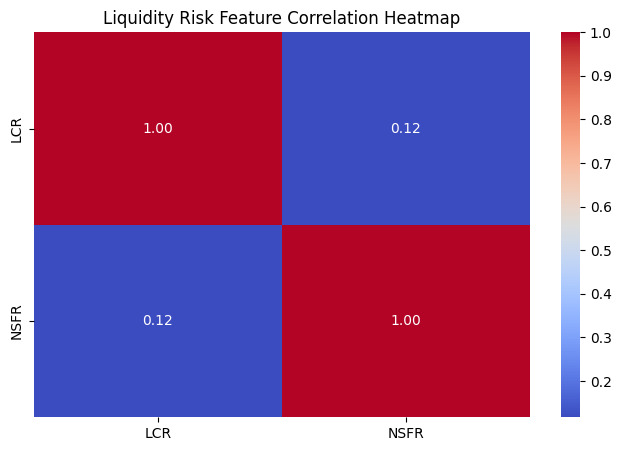

In [24]:

# Visualize Liquidity Risk with a Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df[["LCR", "NSFR"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Liquidity Risk Feature Correlation Heatmap")
plt.show()


In [25]:

# Train a Machine Learning Model to Predict Liquidity Crisis
X = df[["LCR", "NSFR"]]
y = df["Liquidity Crisis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [26]:

# Display Model Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 95.00%


In [27]:

# Predict Liquidity Risk for a New Bank
new_bank = pd.DataFrame({"LCR": [85], "NSFR": [95]})
prediction = model.predict(new_bank)
pred_prob = model.predict_proba(new_bank)[0][1]  # Probability of liquidity crisis



In [28]:

print("Liquidity Crisis Risk:", "High" if prediction[0] == 1 else "Low", f"(Probability: {pred_prob:.2%})")


Liquidity Crisis Risk: High (Probability: 100.00%)
